## BES Rainfall Analysis Project Number: 26009003
Test Aquarius data downloader and gaps analysis
Jamie Feldman 
3/17/2026

In [41]:
import os
import gage_analysis
import matplotlib.pyplot as plt
from datetime import date

import importlib
importlib.reload(gage_analysis)

today = date.today()

data_path = 'C:\\Users\\jfeldman\\OneDrive - Geosyntec\\BES_SPEC_MOD_ONCALL_TEAM - GC001_BES_Rainfall_Analysis_Task\\Code\\Outputs'

In [2]:
latest = gage_analysis.find_latest_database(data_path)
all_data = gage_analysis.load_database_to_dataframe(latest)

15:24:06 - INFO - Looking for database files in C:\Users\jfeldman\OneDrive - Geosyntec\BES_SPEC_MOD_ONCALL_TEAM - GC001_BES_Rainfall_Analysis_Task\Code\Outputs...
15:24:06 - INFO - Found 1 database file(s)
15:24:06 - INFO - Using database: C:\Users\jfeldman\OneDrive - Geosyntec\BES_SPEC_MOD_ONCALL_TEAM - GC001_BES_Rainfall_Analysis_Task\Code\Outputs\precipitation_15min_downloaded_2026-03-11.db
15:24:06 - INFO - Loading data from database
15:24:27 - INFO - Loaded 17,633,712 rows from database
15:24:50 - INFO -   Example: 1976-04-01 00:10:00-08:00 -> 1976-04-01 00:15:00-08:00
15:24:50 - INFO - Pivoting to wide format
15:24:55 - INFO - Result: 1,751,178 timestamps x 11 gages
15:24:55 - INFO - Gages: HYDRA-1, HYDRA-10, HYDRA-12, HYDRA-14, HYDRA-145...


In [7]:
all_data

location,HYDRA-1,HYDRA-10,HYDRA-12,HYDRA-14,HYDRA-145,HYDRA-153,HYDRA-2,HYDRA-3,HYDRA-4,HYDRA-58,HYDRA-6
timestamp_aligned,,,,,,,,,,,
1976-04-01 00:15:00-08:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN
1976-04-01 00:30:00-08:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN
1976-04-01 00:45:00-08:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN
1976-04-01 01:00:00-08:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN
1976-04-01 01:15:00-08:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
2026-03-11 12:30:00-08:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.01
2026-03-11 12:45:00-08:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.02
2026-03-11 13:00:00-08:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.03


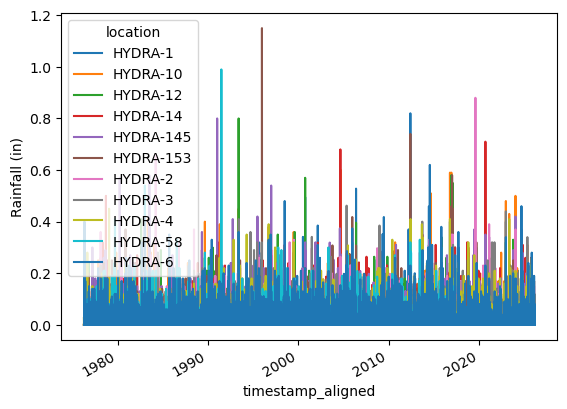

In [33]:
ax = all_data.plot(ylabel='Rainfall (in)')
ax.get_figure().savefig(os.path.join(data_path, '15-min_Rainfall_'+str(today)+'.png'))

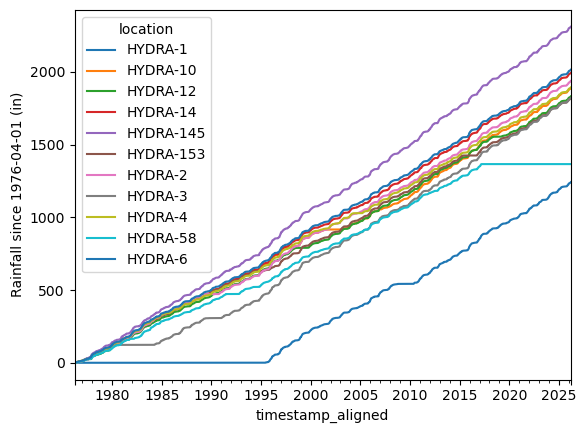

In [ ]:
cumsum = all_data.cumsum().plot(ylabel='Rainfall since 1976-04-01 (in)')
cumsum.get_figure().savefig(os.path.join(data_path, 'Cumulative_Sum_'+str(today)+'.png'))

In [8]:
gage_analysis.investigate_true_missingness(all_data)


Gage         Started                Total After  Missing      % Missing 
----------------------------------------------------------------------
HYDRA-1      1995-05-18 13:30:00    1,080,469    54,680       5.1       %
HYDRA-10     1976-04-02 00:00:00    1,751,083    117,523      6.7       %
HYDRA-12     1976-04-02 00:00:00    1,751,083    66,532       3.8       %
HYDRA-14     1976-04-02 00:00:00    1,751,083    13,622       0.8       %
HYDRA-145    1976-04-30 08:45:00    1,748,360    14,542       0.8       %
HYDRA-153    1976-04-02 00:00:00    1,751,083    66,260       3.8       %
HYDRA-2      1976-05-26 10:45:00    1,745,856    63,964       3.7       %
HYDRA-3      1976-05-26 14:30:00    1,745,841    196,592      11.3      %
HYDRA-4      1976-04-01 00:15:00    1,751,178    37,973       2.2       %
HYDRA-58     1976-05-21 15:45:00    1,746,316    298,266      17.1      %
HYDRA-6      1976-04-02 00:00:00    1,751,083    10,395       0.6       %


In [14]:
all_data['HYDRA-4'].isna().sum()/1751178

np.float64(0.021684260537763723)

In [16]:
len(all_data)

1751178

In [42]:
gage_analysis.analyze_gage_coobservation(all_data, 'HYDRA-4')

{'gage': 'HYDRA-4',
 'pct_missing': np.float64(2.17),
 'pct_others_observe_when_missing': np.float64(100.0),
 'pct_all_missing_when_missing': np.float64(0.0),
 'other_rain_05th': np.float64(0.0),
 'other_rain_25th': np.float64(0.0),
 'other_rain_50th': np.float64(0.0),
 'other_rain_75th': np.float64(0.0),
 'other_rain_95th': np.float64(0.0),
 'other_rain_99th': np.float64(0.022),
 'other_rain_max': np.float64(0.68),
 'n_coobservations': 379730}

In [39]:
gage_analysis.analyze_all_gages(all_data)

16:28:28 - INFO - [1/11] Analyzing HYDRA-1...
16:28:29 - INFO - [2/11] Analyzing HYDRA-10...
16:28:29 - INFO - [3/11] Analyzing HYDRA-12...
16:28:29 - INFO - [4/11] Analyzing HYDRA-14...
16:28:29 - INFO - [5/11] Analyzing HYDRA-145...
16:28:29 - INFO - [6/11] Analyzing HYDRA-153...
16:28:29 - INFO - [7/11] Analyzing HYDRA-2...
16:28:29 - INFO - [8/11] Analyzing HYDRA-3...
16:28:29 - INFO - [9/11] Analyzing HYDRA-4...
16:28:29 - INFO - [10/11] Analyzing HYDRA-58...
16:28:29 - INFO - [11/11] Analyzing HYDRA-6...


,gage,pct_missing,pct_others_observe_when_missing,pct_all_missing_when_missing,other_rain_05th,other_rain_25th,other_rain_50th,other_rain_75th,other_rain_95th,other_rain_99th,n_coobservations
0,HYDRA-1,41.42,100.0,0.0,0.0,0.0,0.0,0.0,0.01,0.022,7253890
1,HYDRA-10,6.72,100.0,0.0,0.0,0.0,0.0,0.0,0.01,0.033,1176180
2,HYDRA-12,3.80,100.0,0.0,0.0,0.0,0.0,0.0,0.01,0.030,666270
3,HYDRA-14,0.78,100.0,0.0,0.0,0.0,0.0,0.0,0.00,0.020,137170
4,HYDRA-145,0.99,100.0,0.0,0.0,0.0,0.0,0.0,0.00,0.020,173600
5,HYDRA-153,3.79,100.0,0.0,0.0,0.0,0.0,0.0,0.01,0.030,663550
6,HYDRA-2,3.96,100.0,0.0,0.0,0.0,0.0,0.0,0.00,0.020,692860
7,HYDRA-3,11.53,100.0,0.0,0.0,0.0,0.0,0.0,0.01,0.030,2019290
8,HYDRA-4,2.17,100.0,0.0,0.0,0.0,0.0,0.0,0.00,0.022,379730
9,HYDRA-58,17.31,100.0,0.0,0.0,0.0,0.0,0.0,0.01,0.030,3031280


In [43]:
gage_analysis.save_results(gage_analysis.analyze_all_gages(all_data), data_path)

17:34:35 - INFO - [1/11] Analyzing HYDRA-1...
17:34:35 - INFO - [2/11] Analyzing HYDRA-10...
17:34:35 - INFO - [3/11] Analyzing HYDRA-12...
17:34:35 - INFO - [4/11] Analyzing HYDRA-14...
17:34:35 - INFO - [5/11] Analyzing HYDRA-145...
17:34:35 - INFO - [6/11] Analyzing HYDRA-153...
17:34:35 - INFO - [7/11] Analyzing HYDRA-2...
17:34:35 - INFO - [8/11] Analyzing HYDRA-3...
17:34:35 - INFO - [9/11] Analyzing HYDRA-4...
17:34:35 - INFO - [10/11] Analyzing HYDRA-58...
17:34:35 - INFO - [11/11] Analyzing HYDRA-6...
17:34:35 - INFO - Results saved to: C:\Users\jfeldman\OneDrive - Geosyntec\BES_SPEC_MOD_ONCALL_TEAM - GC001_BES_Rainfall_Analysis_Task\Code\Outputs\coobservation_analysis_2026-03-17_1734.csv


'C:\\Users\\jfeldman\\OneDrive - Geosyntec\\BES_SPEC_MOD_ONCALL_TEAM - GC001_BES_Rainfall_Analysis_Task\\Code\\Outputs\\coobservation_analysis_2026-03-17_1734.csv'